# Lab1 Analysis (Variant 6)
Считывание результатов C# и построение графиков.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('..') / 'data'
files = {
    'Euler': DATA_DIR / 'euler.csv',
    'Heun': DATA_DIR / 'heun.csv',
    'RungeKutta4': DATA_DIR / 'rungekutta4.csv',
}
frames = {name: pd.read_csv(path) for name, path in files.items()}
summary = pd.DataFrame({
    name: {
        'max_abs_error': df['abs_error'].max(),
        'max_rel_error': df['rel_error'].max(),
    }
    for name, df in frames.items()
}).T
summary


,max_abs_error,max_rel_error
Euler,2.659478e-03,3.338048e-03
Heun,4.876432e-06,6.220303e-06
RungeKutta4,6.223577e-12,8.826949e-12


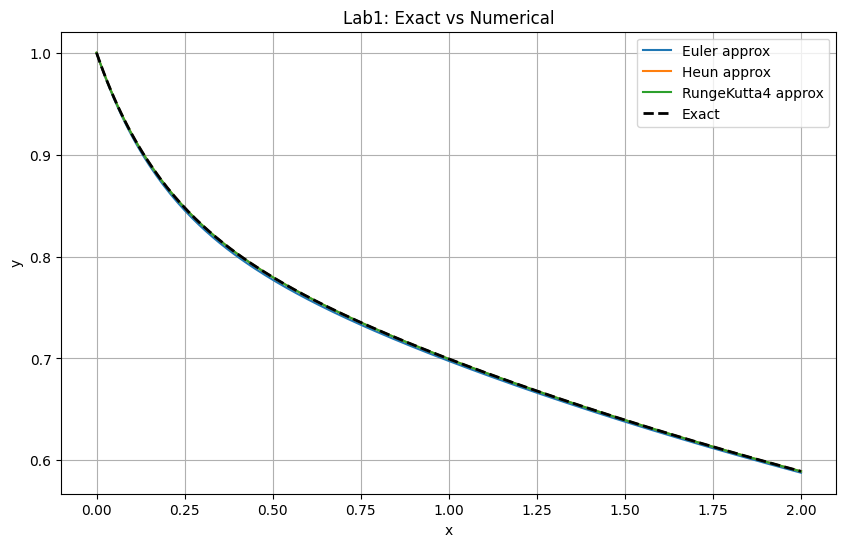

In [2]:
plt.figure(figsize=(10, 6))
for name, df in frames.items():
    plt.plot(df['x'], df['approx'], label=f'{name} approx')

plt.plot(next(iter(frames.values()))['x'], next(iter(frames.values()))['exact'], 'k--', linewidth=2, label='Exact')
plt.title('Lab1: Exact vs Numerical')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()


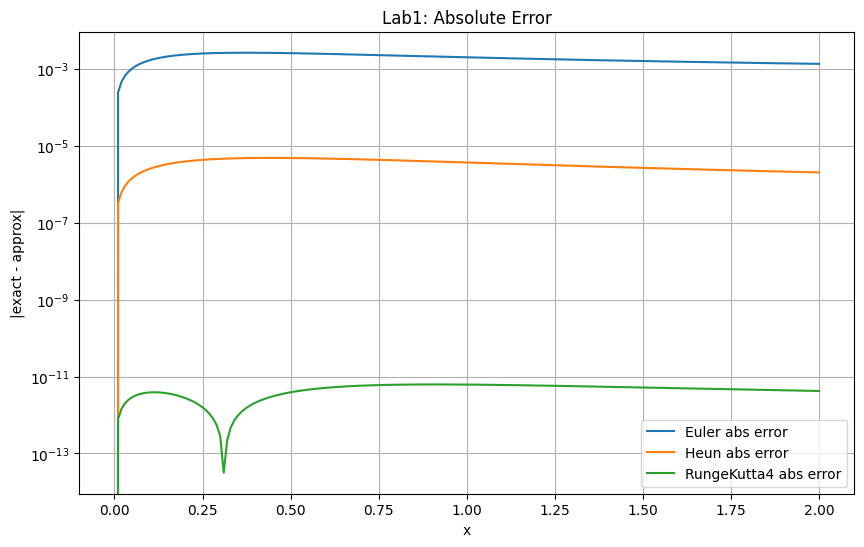

In [3]:
plt.figure(figsize=(10, 6))
for name, df in frames.items():
    plt.plot(df['x'], df['abs_error'], label=f'{name} abs error')

plt.title('Lab1: Absolute Error')
plt.xlabel('x')
plt.ylabel('|exact - approx|')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()
